# Day 1 hands-on: classifiers and the likelihood ratio

In the lecture we saw that a classifier trained with the binary cross entropy learns the signal probability
$$C_\theta(x) = P_\theta(S|x) \qquad \text{and} \qquad \frac{C_\theta(x)}{1-C_\theta(x)} = \frac{P(S)}{P(B)} \, \frac{p(x|S)}{p(x|B)} \; .$$
In this session we
1. look at the few PyTorch commands we need,
2. train a classifier on the two-moons dataset,
3. find out *why* it performs the way it does by plotting what it has learned,
4. build a better network.

**Colab:** everything runs on the CPU in a few seconds, no GPU runtime needed. Run the cells from top to bottom with `Shift+Enter`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from sklearn.datasets import make_moons

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

torch.manual_seed(42)
np.random.seed(42)

## 0) PyTorch reference

The next cells are a reference you can come back to. Run them and look at the output, there is nothing to do here.

### Tensors
PyTorch works with `torch.tensor` objects. They behave very much like `numpy` arrays.

In [2]:
a = torch.tensor([1.0, 2.0, 3.0])
b = torch.ones(3)

print("a + b     =", a + b)
print("a * b     =", a * b)          # element-wise
print("a @ b     =", a @ b)          # scalar product
print("shape     =", torch.zeros(4, 2).shape)
print("to numpy  =", a.numpy())
print("from numpy=", torch.from_numpy(np.array([1.0, 2.0])))

a + b     = tensor([2., 3., 4.])
a * b     = tensor([1., 2., 3.])
a @ b     = tensor(6.)
shape     = torch.Size([4, 2])
to numpy  = [1. 2. 3.]
from numpy= tensor([1., 2.], dtype=torch.float64)


### Automatic gradients: the lecture example
PyTorch computes derivatives for us (back-propagation). Here is the example from the blackboard: one data point $(x,y)=(1,1)$, the model $f_\theta(x)=a$ with start value $a=2$, and the loss $\mathcal{L} = (f_\theta(x) - y)^2$. We expect $\partial \mathcal{L}/\partial a = 2(a-1) = 2$, and with learning rate $\eta=1/2$ one step brings us to $a=1$.

dL/da = 2.0
a after one step = 1.0


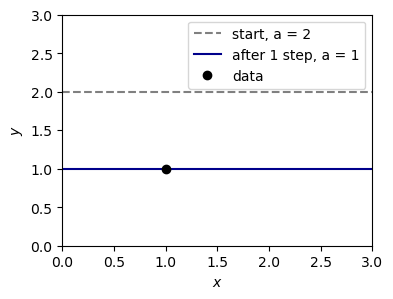

In [3]:
x, y = torch.tensor(1.0), torch.tensor(1.0)
a = torch.tensor(2.0, requires_grad=True)   # a parameter we want gradients for
a_start = a.item()

loss = (a - y)**2
loss.backward()                              # back-propagation
print("dL/da =", a.grad.item())

with torch.no_grad():                        # the update itself is not part of the model
    a -= 0.5 * a.grad
print("a after one step =", a.item())

# data point and model f(x) = a before and after the step
x_line = np.linspace(0, 3, 2)
plt.figure(figsize=(4, 3))
plt.plot(x_line, [a_start, a_start], color="grey", ls="--", label=f"start, a = {a_start:.0f}")
plt.plot(x_line, [a.item(), a.item()], color="darkblue", label=f"after 1 step, a = {a.item():.0f}")
plt.plot(x.item(), y.item(), "o", color="black", label="data")
plt.xlim(0, 3)
plt.ylim(0, 3)
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.legend()
plt.show()

The exercise from the lecture: three points, the model $f_\theta(x) = ax+b$ starting at $a=b=1$, the MSE loss, and one step with $\eta=0.1$. Compare with your numbers from the blackboard. This time we let an **optimizer** do the update step.

L = 2.000,  dL/da = 6.000,  dL/db = 2.667
after one step: a = 0.400, b = 0.733


after 2000 steps: a = 0.500, b = 0.667, L = 0.0556


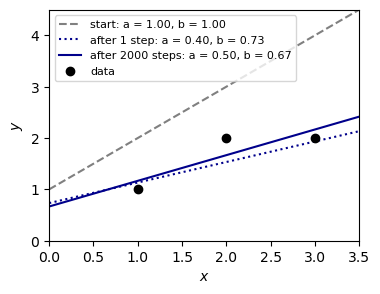

In [4]:
x = torch.tensor([1.0, 2.0, 3.0])
y = torch.tensor([1.0, 2.0, 2.0])
a = torch.tensor(1.0, requires_grad=True)
b = torch.tensor(1.0, requires_grad=True)
optimizer = torch.optim.SGD([a, b], lr=0.1)
models = {"start": (a.item(), b.item())}

loss = ((a * x + b - y)**2).mean()
optimizer.zero_grad()     # reset gradients from earlier steps
loss.backward()           # compute gradients
print(f"L = {loss.item():.3f},  dL/da = {a.grad.item():.3f},  dL/db = {b.grad.item():.3f}")
optimizer.step()          # a -> a - lr * dL/da, same for b
print(f"after one step: a = {a.item():.3f}, b = {b.item():.3f}")
models["after 1 step"] = (a.item(), b.item())

# many steps: gradient descent converges to the least-squares fit a = 1/2, b = 2/3
for step in range(2000):
    loss = ((a * x + b - y)**2).mean()
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
print(f"after 2000 steps: a = {a.item():.3f}, b = {b.item():.3f}, L = {loss.item():.4f}")
models["after 2000 steps"] = (a.item(), b.item())

# data points and the model f(x) = a x + b at the three stages
x_line = np.linspace(0, 3.5, 2)
styles = {"start": dict(color="grey", ls="--"),
          "after 1 step": dict(color="darkblue", ls=":"),
          "after 2000 steps": dict(color="darkblue", ls="-")}
plt.figure(figsize=(4, 3))
for name, (a_val, b_val) in models.items():
    plt.plot(x_line, a_val * x_line + b_val, **styles[name],
             label=f"{name}: a = {a_val:.2f}, b = {b_val:.2f}")
plt.plot(x, y, "o", color="black", label="data")
plt.xlim(0, 3.5)
plt.ylim(0, 4.5)
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.legend(fontsize=8, loc="upper left")
plt.show()

### Datasets and data loaders
A `DataLoader` cuts a dataset into shuffled minibatches.

In [5]:
features = torch.randn(10, 2)          # 10 points in 2 dimensions
labels = torch.randint(0, 2, (10,)).float()

dataset = TensorDataset(features, labels)
loader = DataLoader(dataset, batch_size=4, shuffle=True)

for x_batch, y_batch in loader:
    print(x_batch.shape, y_batch)

torch.Size([4, 2]) tensor([1., 1., 0., 0.])
torch.Size([4, 2]) tensor([1., 0., 0., 1.])
torch.Size([2, 2]) tensor([1., 0.])


### Networks
A network is a class derived from `nn.Module`. The layers are defined in `__init__`, and `forward` says how an input flows through them.

In [6]:
class TinyNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(2, 8)    # 2 inputs -> 8 nodes, x -> W x + b
        self.layer2 = nn.Linear(8, 1)    # 8 nodes  -> 1 output

    def forward(self, x):
        x = self.layer1(x)
        x = torch.relu(x)                # activation function
        x = self.layer2(x)
        return x

net = TinyNet()
print(net)
print("output shape:", net(torch.randn(5, 2)).shape)
print("parameters:  ", sum(p.numel() for p in net.parameters()))

TinyNet(
  (layer1): Linear(in_features=2, out_features=8, bias=True)
  (layer2): Linear(in_features=8, out_features=1, bias=True)
)
output shape: torch.Size([5, 1])
parameters:   33


### Training loop
Every training in this course follows the same pattern:
```python
for epoch in range(n_epochs):
    for x_batch, y_batch in loader:
        prediction = model(x_batch)
        loss = loss_function(prediction, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
```
Useful loss functions: `nn.MSELoss()` for regression, `nn.BCELoss()` for binary classification with outputs in $[0,1]$.

## 1) The two-moons dataset

Two interleaved half circles in two dimensions, with some Gaussian noise. We call the lower moon (label 1) signal and the upper moon (label 0) background. Both classes have the same number of events, so $P(S) = P(B) = 1/2$.

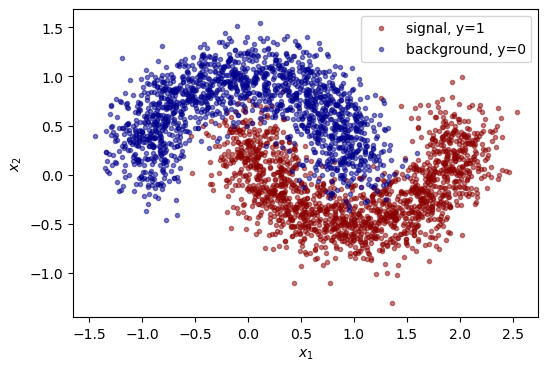

In [7]:
x_np, y_np = make_moons(n_samples=4000, noise=0.2, random_state=42)
x_all = torch.tensor(x_np, dtype=torch.float32)
y_all = torch.tensor(y_np, dtype=torch.float32)

# 80% training, 20% test data
perm = torch.randperm(len(x_all))
n_train = int(0.8 * len(x_all))
x_train, y_train = x_all[perm[:n_train]], y_all[perm[:n_train]]
x_test, y_test = x_all[perm[n_train:]], y_all[perm[n_train:]]

train_loader = DataLoader(TensorDataset(x_train, y_train), batch_size=128, shuffle=True)

def plot_data(x, y, ax=None, alpha=0.5):
    ax = ax or plt.gca()
    ax.plot(x[y == 1, 0], x[y == 1, 1], ".", color="darkred", alpha=alpha, label="signal, y=1")
    ax.plot(x[y == 0, 0], x[y == 0, 1], ".", color="darkblue", alpha=alpha, label="background, y=0")
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")

plt.figure(figsize=(6, 4))
plot_data(x_train, y_train)
plt.legend()
plt.show()

## 2) A first classifier

The simplest classifier: one linear layer from 2 inputs to 1 output, followed by a sigmoid, so the output $C_\theta(x) \in [0,1]$. We call an event signal if $C_\theta(x) > 0.5$.

In [8]:
class LinearClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer = nn.Linear(2, 1)

    def forward(self, x):
        x = self.layer(x)
        x = torch.sigmoid(x)
        return x.squeeze(-1)      # shape (batch, 1) -> (batch,)


def train(model, loader, n_epochs, lr):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_function = nn.BCELoss()
    for epoch in range(n_epochs):
        for x_batch, y_batch in loader:
            loss = loss_function(model(x_batch), y_batch)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        if epoch % 10 == 0 or epoch == n_epochs - 1:
            print(f"epoch {epoch:3d}   loss {loss.item():.4f}")


def accuracy(model, x, y):
    with torch.no_grad():
        prediction = (model(x) > 0.5).float()
    return (prediction == y).float().mean().item()

In [9]:
model_linear = LinearClassifier()
train(model_linear, train_loader, n_epochs=20, lr=1e-2)
print(f"\ntest accuracy: {accuracy(model_linear, x_test, y_test):.3f}")

epoch   0   loss 0.7969


epoch  10   loss 0.3509


epoch  19   loss 0.3328

test accuracy: 0.869


The accuracy is well below what we would expect for two moons that are clearly separated by eye. Training longer does not help. To understand why, we need to look at what the network has learned.

## 3) Exercise 1: what has the network learned?

We evaluate the trained network on a fine grid over the $(x_1, x_2)$ plane and plot the result as a colour map. The helper functions below do all of this. What they do **not** know is *which quantity* to plot.

From the lecture, the network output is $C_\theta(x) = P_\theta(S|x)$, and the quantity that tells us how signal-like a phase space point is, independent of the class composition, is the **likelihood ratio**.

**Task:** compute the likelihood ratio learned by the network from its output `C` and plot it. Choose the contour `level` of the likelihood ratio that corresponds to our cut $C > 0.5$. Why is the accuracy limited?

In [10]:
def make_grid(n=200):
    x1 = torch.linspace(-1.7, 2.7, n)
    x2 = torch.linspace(-1.2, 1.7, n)
    X1, X2 = torch.meshgrid(x1, x2, indexing="xy")
    points = torch.stack([X1.flatten(), X2.flatten()], dim=1)
    return X1, X2, points


def plot_on_grid(X1, X2, values, level=None, log=False, title=""):
    values = values.reshape(X1.shape)
    plt.figure(figsize=(7, 4.5))
    norm = LogNorm(vmin=1e-3, vmax=1e3) if log else None
    mesh = plt.pcolormesh(X1, X2, values.clip(1e-3, 1e3) if log else values,
                          cmap="RdBu_r", norm=norm, shading="auto")
    plt.colorbar(mesh)
    if level is not None:
        plt.contour(X1, X2, values, levels=[level], colors="black", linewidths=2)
    plot_data(x_test, y_test, alpha=0.3)
    plt.title(title)
    plt.show()


X1, X2, grid_points = make_grid()

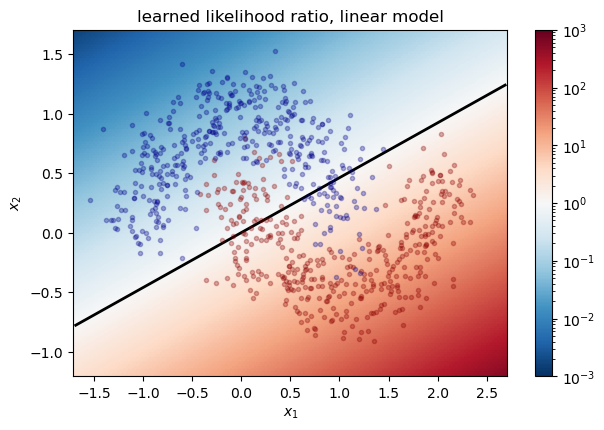

In [11]:
with torch.no_grad():
    C = model_linear(grid_points)          # network output on the grid

########################################
### Choose what to plot here ###
quantity = C / (1 - C)                    # learned likelihood ratio p(x|S)/p(x|B), P(S)=P(B)
level = 1.0                               # C = 0.5  <=>  C/(1-C) = 1
########################################

plot_on_grid(X1, X2, quantity, level=level, log=True, title="learned likelihood ratio, linear model")

**Solution:** for balanced classes the likelihood ratio is $r(x) = C/(1-C)$, and the cut $C > 0.5$ is the contour $r = 1$. For our model
$$\log r(x) = \log\frac{C}{1-C} = \text{Logit}\big(\sigma(w \cdot x + b)\big) = w \cdot x + b \; ,$$
so the logarithm of the learned likelihood ratio is a *plane*, and every contour, including the decision boundary, is a straight line. The true boundary between the moons is curved, so no choice of $w$ and $b$ can separate them: the network is not expressive enough.

## 4) Exercise 2: a more expressive network

To learn a curved likelihood ratio we need more layers and a non-linearity between them. The cell below lists building blocks from `torch.nn`. Not all of them are useful here.

In [12]:
# ---- building blocks, cheat sheet ------------------------------------------
nn.Linear(4, 8)                  # affine layer x -> W x + b, 4 inputs -> 8 outputs
nn.ReLU()                        # max(0, x), element-wise
nn.Tanh()                        # tanh(x), element-wise, output in [-1, 1]
nn.Sigmoid()                     # 1 / (1 + exp(-x)), element-wise, output in [0, 1]
nn.Softmax(dim=-1)               # exp(x_i) / sum_j exp(x_j), outputs sum to 1
nn.Dropout(p=0.1)                # randomly sets entries to 0 during training
nn.BatchNorm1d(8)                # normalizes each of 8 features over the batch
nn.Conv2d(1, 8, kernel_size=3)   # convolution over 2D images
# functional versions for use inside forward(): torch.relu(x), torch.tanh(x), torch.sigmoid(x)
# -----------------------------------------------------------------------------

Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1))

**Task:** write a network `DeepClassifier` with at least two hidden layers and ReLU activations. The output has to be a single number in $[0,1]$ per event.

In [13]:
class DeepClassifier(nn.Module):
    def __init__(self, n_hidden=64):
        super().__init__()
        ########################################
        ### Define your layers here ###
        self.layer1 = nn.Linear(2, n_hidden)
        self.layer2 = nn.Linear(n_hidden, n_hidden)
        self.layer3 = nn.Linear(n_hidden, 1)
        ########################################

    def forward(self, x):
        ########################################
        ### Define the forward pass here ###
        x = torch.relu(self.layer1(x))
        x = torch.relu(self.layer2(x))
        x = torch.sigmoid(self.layer3(x))
        ########################################
        return x.squeeze(-1)

**Solution notes:** the non-linearity between the layers is essential. Without it, three linear layers collapse into one linear map and we are back at the straight line. Traps in the cheat sheet:
* `nn.Softmax` on a single output always returns 1, so the network output is constant and cannot learn anything.
* `nn.ReLU` or no activation on the last layer gives outputs outside $[0,1]$, and `nn.BCELoss` refuses them.
* `nn.Conv2d` needs images as input, not points.
* `nn.Dropout` and `nn.BatchNorm1d` work, but do not add expressivity.

## 5) Exercise 3: train the new network

**Task:** train your `DeepClassifier` and compare the test accuracy to the linear model. Try a few settings for the number of epochs and the learning rate.

In [14]:
model_deep = DeepClassifier()
print("parameters:", sum(p.numel() for p in model_deep.parameters()))

########################################
### Modify training parameters here ###
n_epochs = 50
lr = 1e-3
########################################

train(model_deep, train_loader, n_epochs=n_epochs, lr=lr)
print(f"\ntest accuracy, linear model: {accuracy(model_linear, x_test, y_test):.3f}")
print(f"test accuracy, deep model:   {accuracy(model_deep, x_test, y_test):.3f}")

parameters: 4417
epoch   0   loss 0.5019


epoch  10   loss 0.0946


epoch  20   loss 0.0855


epoch  30   loss 0.1359


epoch  40   loss 0.0768


epoch  49   loss 0.1482

test accuracy, linear model: 0.869
test accuracy, deep model:   0.971


**Solution notes:** with enough epochs the deep network reaches about 97% accuracy. It does not reach 100%, because the noise makes the two moons overlap: in the overlap region even the true $P(S|x)$ is close to $1/2$, and no classifier can do better than the true likelihood ratio.

## 6) Exercise 4: the new likelihood ratio

**Task:** plot the likelihood ratio learned by the deep network, as in Exercise 1. What has changed? Where do you trust the learned ratio, and where not?

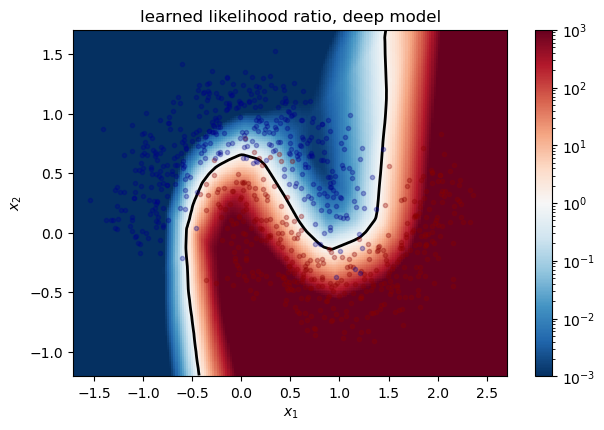

In [15]:
with torch.no_grad():
    C = model_deep(grid_points)

########################################
### Choose what to plot here ###
quantity = C / (1 - C)
level = 1.0
########################################

plot_on_grid(X1, X2, quantity, level=level, log=True, title="learned likelihood ratio, deep model")

**Solution notes:** the decision boundary $r=1$ now follows the curved gap between the moons. Close to the data the ratio changes smoothly across the overlap region, where the classes mix. Far away from the data, in the corners of the plot, the network still returns very large or very small ratios, but there is no training data there: the likelihood ratio is only meaningful where both $p(x|S)$ and $p(x|B)$ are supported by data. We will come back to this on Day 3.

## 7) Bonus: from a cut to the ROC curve

So far we called an event signal if $C_\theta(x) > 0.5$. Nothing forces us to cut at $0.5$. For any cut value $c$ we can count
* the **signal efficiency** or true positive rate, $\epsilon_S(c)$ = fraction of signal events with $C > c$,
* the **background efficiency** or false positive rate, $\epsilon_B(c)$ = fraction of background events with $C > c$.

**Bonus Task, step 1:** complete the function `efficiencies` and look at the distributions of the network output for signal and background test events. Which efficiencies do we get for the cut at $0.5$?

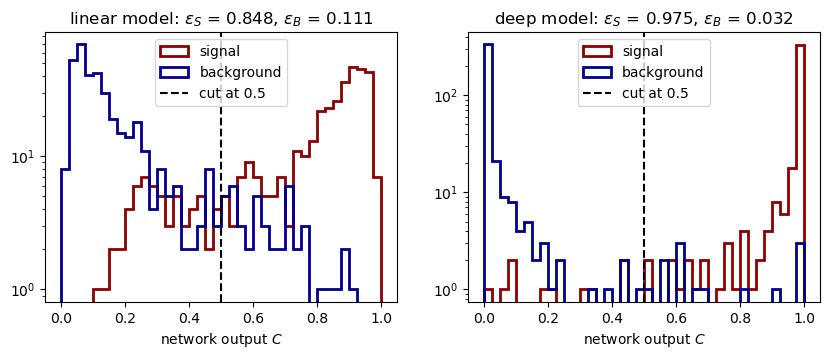

In [16]:
with torch.no_grad():
    C_test_linear = model_linear(x_test)
    C_test_deep = model_deep(x_test)


def efficiencies(values, y, cut):
    selected = values > cut
    ########################################
    ### Compute the efficiencies here ###
    eps_S = selected[y == 1].float().mean().item()    # true positive rate
    eps_B = selected[y == 0].float().mean().item()    # false positive rate
    ########################################
    return eps_S, eps_B


cut = 0.5
bins = np.linspace(0, 1, 41)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
for ax, C_test, name in zip(axes, [C_test_linear, C_test_deep], ["linear model", "deep model"]):
    ax.hist(C_test[y_test == 1], bins, histtype="step", color="darkred", lw=2, label="signal")
    ax.hist(C_test[y_test == 0], bins, histtype="step", color="darkblue", lw=2, label="background")
    ax.axvline(cut, color="black", ls="--", label=f"cut at {cut}")
    eps_S, eps_B = efficiencies(C_test, y_test, cut)
    ax.set_title(f"{name}: $\\epsilon_S$ = {eps_S:.3f}, $\\epsilon_B$ = {eps_B:.3f}")
    ax.set_xlabel("network output $C$")
    ax.set_yscale("log")
    ax.legend(loc="upper center")
plt.show()

**Bonus Task, step 2:** move the cut. How do $\epsilon_S$ and $\epsilon_B$ change? Can you find a cut with a high signal efficiency *and* a low background efficiency?

In [17]:
########################################
### Modify the cut values here ###
cuts = [0.1, 0.3, 0.5, 0.7, 0.9]
########################################

print("  cut    eps_S   eps_B   (deep model)")
for cut in cuts:
    eps_S, eps_B = efficiencies(C_test_deep, y_test, cut)
    print(f"  {cut:.2f}   {eps_S:.3f}   {eps_B:.3f}")

  cut    eps_S   eps_B   (deep model)
  0.10   0.990   0.086
  0.30   0.985   0.044
  0.50   0.975   0.032
  0.70   0.949   0.012
  0.90   0.909   0.010


**Solution notes:** a tighter cut removes more background, but also loses signal. Every cut is a trade-off between the two efficiencies, and which one we want depends on the analysis: a discovery wants little background, a measurement of a large signal wants high efficiency.

**Bonus Task, step 3:** instead of picking a few cuts, scan all of them and plot $\epsilon_S$ against $\epsilon_B$. This is the **ROC curve** (receiver operating characteristic). Which model is better, and what does the diagonal correspond to? The area under the curve (AUC) summarizes it in one number.

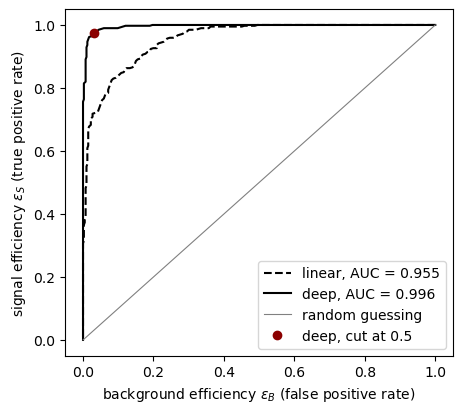

In [18]:
def roc(values, y, n_cuts=200):
    # cut values at the quantiles of the classifier output, works for any range of values
    cut_values = np.quantile(values.numpy(), np.linspace(0, 1, n_cuts))
    cut_values = np.concatenate([[-np.inf], cut_values, [np.inf]])
    eps = np.array([efficiencies(values, y, c) for c in cut_values])
    eps_S, eps_B = eps[:, 0], eps[:, 1]
    auc = np.sum((eps_B[:-1] - eps_B[1:]) * (eps_S[:-1] + eps_S[1:]) / 2)   # trapezoidal rule
    return eps_S, eps_B, auc


plt.figure(figsize=(5, 4.5))
for C_test, name, ls in [(C_test_linear, "linear", "--"), (C_test_deep, "deep", "-")]:
    eps_S, eps_B, auc = roc(C_test, y_test)
    plt.plot(eps_B, eps_S, color="black", ls=ls, label=f"{name}, AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], color="grey", lw=0.8, label="random guessing")
eps_S, eps_B = efficiencies(C_test_deep, y_test, 0.5)
plt.plot(eps_B, eps_S, "o", color="darkred", label="deep, cut at 0.5")
plt.xlabel(r"background efficiency $\epsilon_B$ (false positive rate)")
plt.ylabel(r"signal efficiency $\epsilon_S$ (true positive rate)")
plt.legend(loc="lower right")
plt.show()

**Solution notes:** each point on the curve is one cut, from "select everything" at $(1,1)$ to "select nothing" at $(0,0)$. The better classifier has the higher curve: more signal for the same background. A classifier which does not look at $x$ selects the same fraction of signal and background, which is the diagonal with AUC $= 0.5$; a perfect classifier has AUC $= 1$. In particle physics the same information is often shown as background rejection $1/\epsilon_B$ against $\epsilon_S$ on a log scale, like the top-tagging comparison in the lecture.

**Bonus Task, step 4:** the Neyman-Pearson lemma says that the likelihood ratio is the optimal test statistic, and that any strictly increasing function of it defines the same selections. Test this: compute the ROC curve of the deep model using the learned likelihood ratio $C/(1-C)$ instead of $C$. Then try a function of $C$ which is *not* monotonic, for instance $|C - 0.5|$. What happens?

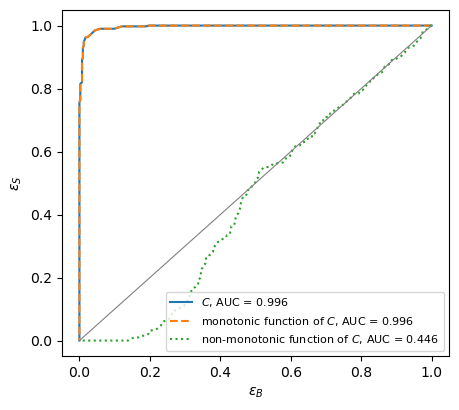

In [19]:
########################################
### Choose the test statistics here ###
quantity_monotonic = C_test_deep / (1 - C_test_deep)
quantity_not_monotonic = (C_test_deep - 0.5).abs()
########################################

plt.figure(figsize=(5, 4.5))
for values, name, ls in [(C_test_deep, "$C$", "-"),
                         (quantity_monotonic, "monotonic function of $C$", "--"),
                         (quantity_not_monotonic, "non-monotonic function of $C$", ":")]:
    eps_S, eps_B, auc = roc(values, y_test)
    plt.plot(eps_B, eps_S, ls=ls, label=f"{name}, AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], color="grey", lw=0.8)
plt.xlabel(r"$\epsilon_B$")
plt.ylabel(r"$\epsilon_S$")
plt.legend(loc="lower right", fontsize=8)
plt.show()

**Solution notes:** the ROC curve for $C/(1-C)$ lies exactly on top of the one for $C$: a cut $C > c$ is the same selection as $C/(1-C) > c/(1-c)$. The ROC curve only depends on the *ordering* of events, not on the values of the test statistic. The non-monotonic $|C-0.5|$ mixes the most signal-like and the most background-like events, and the curve collapses to around the diagonal, AUC $\approx 0.5$: it measures how sure the network is, not which class it prefers.

## 8) Bonus 2: class composition

*Only if the class composition was covered in the lecture.*

In the lecture we saw that $C = P(S|x)$ depends on the fraction of signal events, while the likelihood ratio does not.

**Bonus Task:**
1. Check the calibration: the mean of $C_\theta(x)$ over the full training sample should reproduce the signal fraction $P(S)$.
2. Generate a new dataset with four times fewer signal events, `make_moons(n_samples=(3200, 800), ...)` (the first number is the upper moon, label 0), and train a new `DeepClassifier` on it. Plot $C$ with the level $0.5$: how does the boundary move? Then plot the likelihood ratio including the prior factor, $\frac{P(B)}{P(S)} \frac{C}{1-C}$, and compare it to Exercise 4.

mean C on training data: 0.508
signal fraction P(S):    0.502
epoch   0   loss 0.3948


epoch  10   loss 0.0386


epoch  20   loss 0.0738


epoch  30   loss 0.0892


epoch  40   loss 0.0147


epoch  49   loss 0.0176


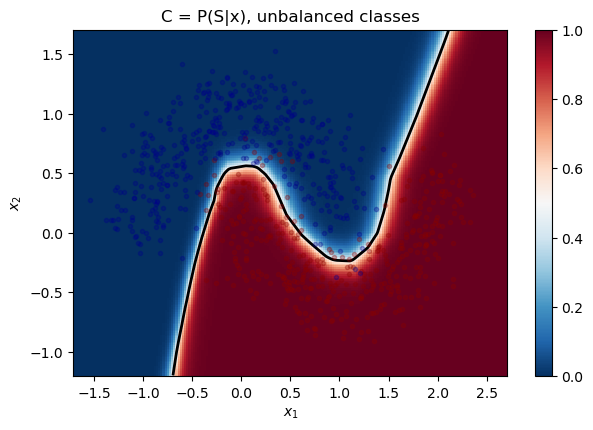

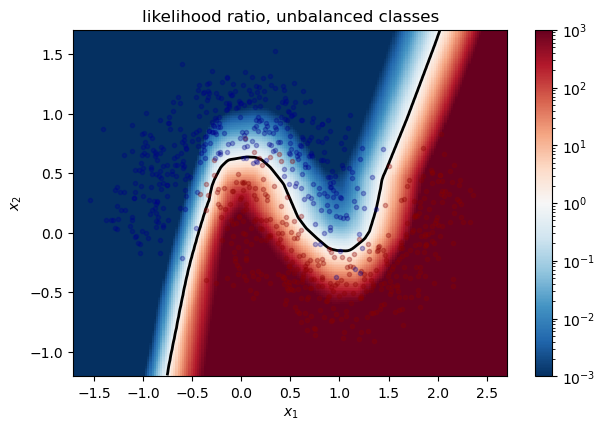

In [20]:
# 1. calibration check
with torch.no_grad():
    print(f"mean C on training data: {model_deep(x_train).mean().item():.3f}")
print(f"signal fraction P(S):    {y_train.mean().item():.3f}")

# 2. unbalanced classes: 3200 background (upper moon), 800 signal (lower moon)
x_np_u, y_np_u = make_moons(n_samples=(3200, 800), noise=0.2, random_state=1)
x_u = torch.tensor(x_np_u, dtype=torch.float32)
y_u = torch.tensor(y_np_u, dtype=torch.float32)
loader_u = DataLoader(TensorDataset(x_u, y_u), batch_size=128, shuffle=True)

model_u = DeepClassifier()
train(model_u, loader_u, n_epochs=50, lr=1e-3)

with torch.no_grad():
    C_u = model_u(grid_points)
prior_ratio = (1 - y_u.mean()) / y_u.mean()     # P(B)/P(S) = 4

plot_on_grid(X1, X2, C_u, level=0.5, title="C = P(S|x), unbalanced classes")
plot_on_grid(X1, X2, prior_ratio * C_u / (1 - C_u), level=1.0, log=True,
             title="likelihood ratio, unbalanced classes")

**Solution notes:** the mean output reproduces $P(S)=1/2$ for the balanced sample. For the unbalanced sample the $C=0.5$ boundary moves into the signal moon, because in the overlap region background events now dominate, exactly like the crossing point in the lecture figure. After multiplying by the prior factor $P(B)/P(S)=4$, the likelihood ratio looks like the one from Exercise 4, up to statistical fluctuations of the smaller signal sample.